# MPSlib: Using masks

This example demonstrates how to use a spatial mask to restrict simulation to specific
regions of the grid, and how to combine two simulations using different training images
in different masked regions.

In [1]:
import mpslib as mps
import matplotlib.pyplot as plt
import numpy as np
import copy
from numpy import squeeze

## Load training images

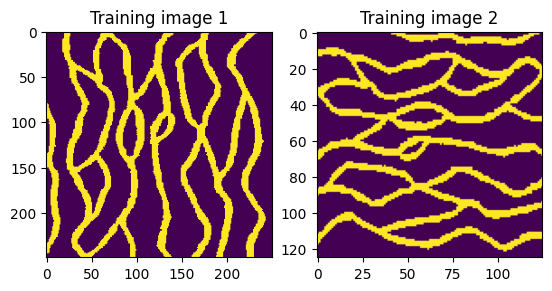

In [2]:
# TI1: Strebelle (original orientation)
TI1, TI_filename1 = mps.trainingimages.strebelle(di=1)
TI1 = np.swapaxes(TI1, 0, 1)
# TI2: Strebelle (rotated and coarsened)
TI2, TI_filename2 = mps.trainingimages.strebelle(di=2)
plt.figure(1)
plt.subplot(1, 2, 1)
plt.imshow(np.transpose(TI1[:, :, 0]))
plt.title('Training image 1')
plt.subplot(1, 2, 2)
plt.imshow(np.transpose(TI2[:, :, 0]))
plt.title('Training image 2')
plt.show()

## Setup MPS object

In [3]:
grid_size = np.array([350, 200, 1])
O = mps.mpslib(method='mps_snesim_tree',
               n_real=1, verbose_level=-1)
#O = mps.mpslib(method='mps_genesim',
#               n_real=1, verbose_level=-1)
O.par['debug_level'] = -1
O.par['n_cond'] = 49
O.par['simulation_grid_size'] = grid_size

# Make sure no unwanted hard/soft data files are being used
O.delete_local_files()

## Define masks

In [4]:
d_mask1 = np.zeros([grid_size[0], grid_size[1], grid_size[2]])
d_mask1[80:150, 100:180] = 1
d_mask1[0:40, 80:150] = 1
d_mask2 = 1 - d_mask1
mask_fnam1 = 'mask_01.dat'
mask_fnam2 = 'mask_02.dat'
mps.eas.write_mat(d_mask1, mask_fnam1)
mps.eas.write_mat(d_mask2, mask_fnam2)

{'dim': {'nx': 350, 'ny': 200, 'nz': 1},
 'n_cols': 1,
 'title': '350 200 1',
 'header': ['Header'],
 'D': array([1., 1., 1., ..., 1., 1., 1.], shape=(70000,))}

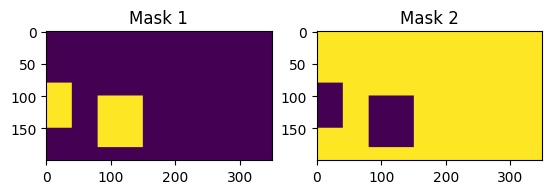

In [5]:
plt.figure(2)
plt.subplot(121)
plt.imshow(np.transpose(np.squeeze(d_mask1)))
plt.title('Mask 1')
plt.subplot(122)
plt.imshow(np.transpose(np.squeeze(d_mask2)))
plt.title('Mask 2')
plt.show()

## Simulate in region 1 (mask 1)

In [6]:
O1 = copy.deepcopy(O)
O1.delete_hard_data()
O1.par['mask_fnam'] = mask_fnam1
O1.ti = TI1
O1.run()

True

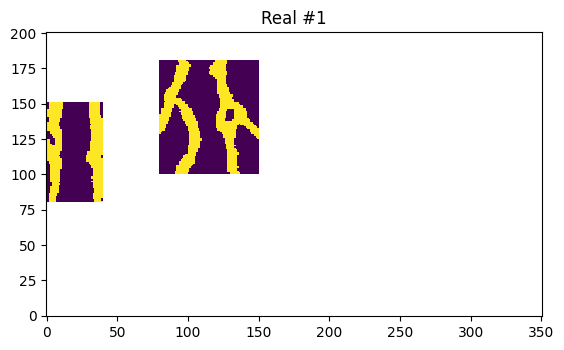

In [7]:
plt.figure(3)
O1.plot_reals()

## Extract hard data from simulation in region 1

In [8]:
d_hard = O1.hard_data_from_sim()

## Simulate in region 2 (mask 2), conditioned on region 1

In [9]:
d_hard = O1.hard_data_from_sim()
O2 = copy.deepcopy(O)
O2.parameter_filename = 'mps_mask2.par'
O2.par['mask_fnam'] = mask_fnam2
O2.ti = TI2
O2.delete_hard_data()
O2.d_hard = d_hard
O2.run()

True

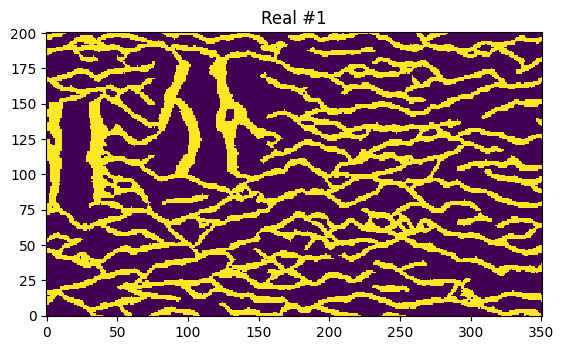

In [10]:
plt.figure(4)
O2.plot_reals()